# Analyse exploratoire des données (EDA)

## Objectif

Analyser les tendances, les profils d'usagers et les circonstances associées à la gravité des accidents entre 2020 et 2024 à l'aide de Python et de visualisations.

In [1555]:
# 1.1. Import des bibliothèques

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [1556]:
# 1.2. Chargement des données nettoyées

accidents = pd.read_csv(
    "data/processed/caract_2020_2024_clean.csv",
    sep=";"
)

lieux = pd.read_csv(
    "data/processed/lieux_2020_2024_clean.csv",
    sep=";"
)

vehicules = pd.read_csv(
    "data/processed/vehicules_2020_2024_clean.csv",
    sep=";"
)

usagers = pd.read_csv(
    "data/processed/usagers_2020_2024_clean.csv",
    sep=";",
    dtype={"id_usager": "string"}
)

In [1557]:
# 1.3. Vérification des dimensions

print("Accidents :", accidents.shape)
print("Lieux :", lieux.shape)
print("Véhicules :", vehicules.shape)
print("Usagers :", usagers.shape)

Accidents : (268788, 16)
Lieux : (294438, 9)
Véhicules : (459137, 8)
Usagers : (612181, 11)


## 2. Évolution temporelle des accidents

In [1558]:
# 2.1. Nombre d'accidents par année

accidents_par_annee = (
    accidents.groupby("annee")["Num_Acc"]
    .nunique()
    .reset_index(name="nombre_accidents")
)

accidents_par_annee

,annee,nombre_accidents
0,2020,47744
1,2021,56518
2,2022,55302
3,2023,54822
4,2024,54402


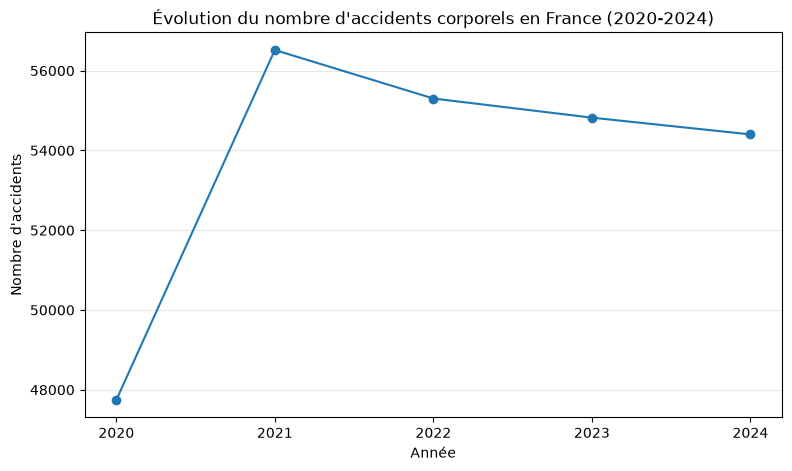

In [1559]:
# 2.2. Évolution annuelle du nombre d'accidents

plt.figure(figsize=(9, 5))

plt.plot(
    accidents_par_annee["annee"],
    accidents_par_annee["nombre_accidents"],
    marker="o"
)

plt.title("Évolution du nombre d'accidents corporels en France (2020-2024)")
plt.xlabel("Année")
plt.ylabel("Nombre d'accidents")
plt.xticks(accidents_par_annee["annee"])
plt.grid(axis="y", alpha=0.3)

plt.show()

**Résultat :** après un niveau particulièrement bas en 2020, le nombre d'accidents augmente fortement en 2021 puis diminue progressivement jusqu'en 2024. Malgré cette baisse récente, le niveau de 2024 reste supérieur à celui de 2020 ce dernier peut être expliqué par la période du covid.

In [1560]:
# 2.3. Évolution mensuelle par année

accidents_mensuels = (
    accidents.groupby(["mois", "annee"])["Num_Acc"]
    .nunique()
    .unstack()
)

accidents_mensuels

annee,2020,2021,2022,2023,2024
mois,,,,,
1,4749,3757,3981,4053,4069
2,4292,3350,3901,3682,3792
3,2609,4105,4529,3998,4370
4,1208,3841,4340,4162,4586
5,3294,4835,5299,4767,4517
6,4389,5865,5418,5452,5135
7,5236,5373,5068,4754,5209
8,4587,4590,4173,4121,4450
9,5472,5671,4919,5161,4620


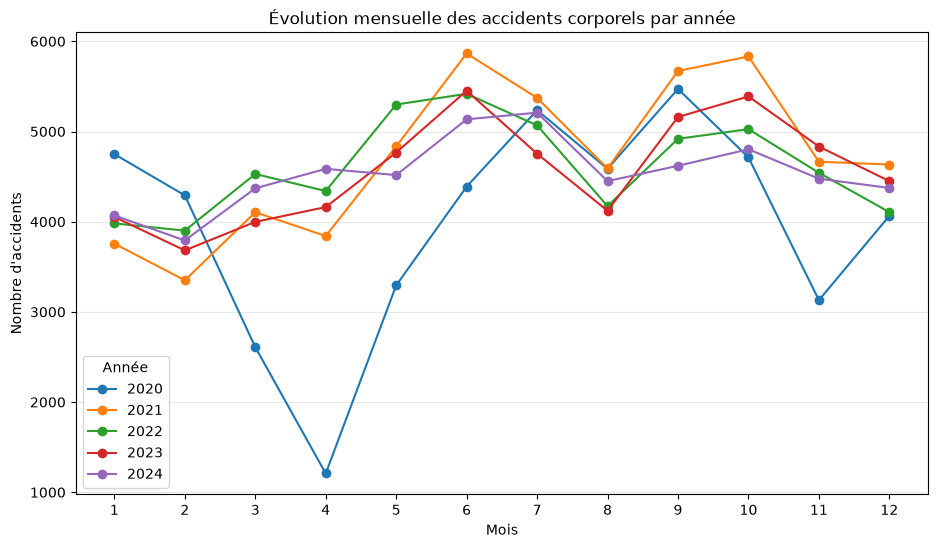

In [1561]:
# 2.4. Évolution mensuelle du nombre d'accidents par année

accidents_mensuels.plot(
    figsize=(11, 6),
    marker="o"
)

plt.title("Évolution mensuelle des accidents corporels par année")
plt.xlabel("Mois")
plt.ylabel("Nombre d'accidents")
plt.xticks(range(1, 13))
plt.legend(title="Année")
plt.grid(axis="y", alpha=0.3)

plt.show()

**Résultat :** l'année 2020 présente une évolution atypique, avec une forte baisse des accidents en mars-avril. À partir de 2021, les évolutions mensuelles sont plus proches, avec des niveaux généralement plus élevés entre mai et juillet ainsi qu'en septembre-octobre. Le mois du maximum varie toutefois selon les années.

## 3. Analyse de la gravité des accidents

In [1562]:
# 3.1. Création de l'indicateur de gravité élevée

usagers["gravite_elevee"] = usagers["gravite"].isin([2, 3])

usagers["gravite_elevee"].value_counts()

gravite_elevee
False    502277
True     109904
Name: count, dtype: int64

In [1563]:
# 3.2. Nombre de gravités manquantes

usagers["gravite"].isna().sum()

np.int64(419)

In [1564]:
# 3.3. Taux global de gravité élevée

usagers_gravite_connue = usagers.dropna(subset=["gravite"])

taux_gravite_elevee = (
    usagers_gravite_connue["gravite_elevee"].mean() * 100
)

round(taux_gravite_elevee, 2)

np.float64(17.97)

**Résultat :** parmi les usagers dont la gravité est renseignée, 17,97 % sont tués ou blessés hospitalisés. Ce taux servira de référence pour comparer les différents profils et circonstances.

## 4. Gravité selon le profil des usagers

In [1565]:
# 4.1. Taux de gravité élevée selon la catégorie d'usager

gravite_par_categorie = (
    usagers_gravite_connue
    .groupby("categorie_usager")["gravite_elevee"]
    .agg(["count", "sum", "mean"])
)

gravite_par_categorie["taux_gravite_elevee"] = (
    gravite_par_categorie["mean"] * 100
).round(2)

gravite_par_categorie.index = gravite_par_categorie.index.map({
    1: "Conducteur",
    2: "Passager",
    3: "Piéton"
})

gravite_par_categorie[
    ["count", "sum", "taux_gravite_elevee"]
]

,count,sum,taux_gravite_elevee
categorie_usager,,,
Conducteur,455498,76429,16.78
Passager,110019,18345,16.67
Piéton,46245,15130,32.72


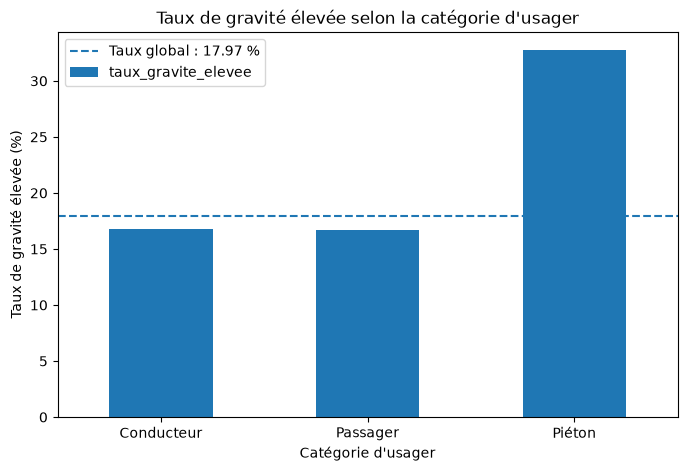

In [1566]:
# 4.2. Taux de gravité élevée selon la catégorie d'usager

gravite_par_categorie["taux_gravite_elevee"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.axhline(
    y=taux_gravite_elevee,
    linestyle="--",
    label=f"Taux global : {taux_gravite_elevee:.2f} %"
)

plt.title("Taux de gravité élevée selon la catégorie d'usager")
plt.xlabel("Catégorie d'usager")
plt.ylabel("Taux de gravité élevée (%)")
plt.xticks(rotation=0)
plt.legend()

plt.show()

**Résultat :** les piétons présentent le taux de gravité élevée le plus important (32,72 %), contre environ 16,7 % pour les conducteurs et les passagers. Leur taux est nettement supérieur au taux global de 17,97 %.

In [1567]:
# 4.3. Calcul de l'âge des usagers

usagers_age = usagers_gravite_connue.merge(
    accidents[["Num_Acc", "annee"]],
    on="Num_Acc",
    how="left"
)

usagers_age["age"] = (
    usagers_age["annee"] - usagers_age["annee_naissance"]
)

usagers_age[["annee", "annee_naissance", "age"]].head()

,annee,annee_naissance,age
0,2020,1983.0,37.0
1,2020,1982.0,38.0
2,2020,1997.0,23.0
3,2020,1967.0,53.0
4,2020,1985.0,35.0


In [1568]:
# 4.4. Contrôle des valeurs extrêmes de l'âge

usagers_age["age"].describe()

count    601062.000000
mean         38.508156
std          18.985377
min           0.000000
25%          23.000000
50%          35.000000
75%          52.000000
max         120.000000
Name: age, dtype: float64

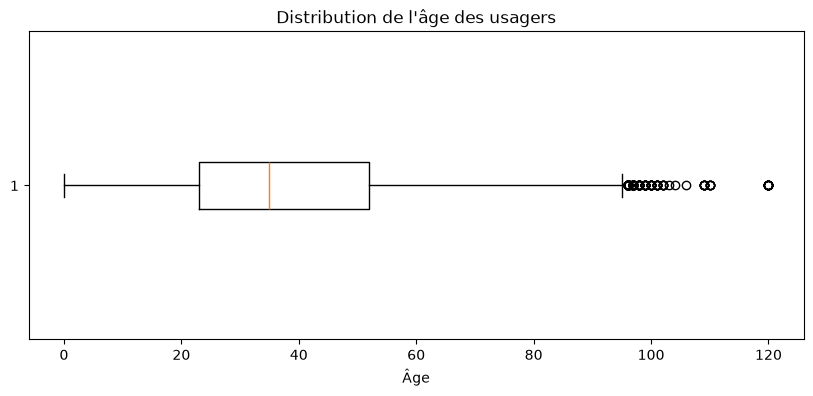

In [1569]:
# 4.5. Distribution de l'âge et valeurs atypiques

plt.figure(figsize=(10, 4))

plt.boxplot(
    usagers_age["age"].dropna(),
    orientation="horizontal"
)

plt.title("Distribution de l'âge des usagers")
plt.xlabel("Âge")

plt.show()

In [1570]:
# 4.6. Contrôle des âges supérieurs à 100 ans

usagers_age.loc[
    usagers_age["age"] > 100,
    "age"
].value_counts().sort_index()

age
101.0     9
102.0     5
103.0     1
104.0     1
106.0     1
109.0     7
110.0     5
120.0    15
Name: count, dtype: int64

In [1571]:
# 4.7. Origine des âges supérieurs à 100 ans

usagers_age.loc[
    usagers_age["age"] > 100,
    ["annee", "annee_naissance", "age"]
].value_counts().sort_index()

annee  annee_naissance  age  
2020   1900.0           120.0    15
       1910.0           110.0     3
2021   1912.0           109.0     1
       1919.0           102.0     1
       1920.0           101.0     2
2022   1913.0           109.0     4
       1920.0           102.0     1
       1921.0           101.0     2
2023   1913.0           110.0     1
       1917.0           106.0     1
       1919.0           104.0     1
       1920.0           103.0     1
       1921.0           102.0     2
       1922.0           101.0     3
2024   1914.0           110.0     1
       1915.0           109.0     2
       1922.0           102.0     1
       1923.0           101.0     2
Name: count, dtype: int64

**Traitement :** les âges supérieurs à 100 ans (44 observations) sont exclus uniquement de l'analyse par âge en raison de leur caractère extrême. Les données sources ne sont pas modifiées.

In [1572]:
# 4.8. Création des tranches d'âge

usagers_age_analyse = usagers_age[
    usagers_age["age"].between(0, 100)
].copy()

usagers_age_analyse["tranche_age"] = pd.cut(
    usagers_age_analyse["age"],
    bins=[0, 13, 17, 24, 44, 64, 74, 84, 100],
    labels=[
        "0-13 ans",
        "14-17 ans",
        "18-24 ans",
        "25-44 ans",
        "45-64 ans",
        "65-74 ans",
        "75-84 ans",
        "85 ans et plus"
    ],
    include_lowest=True
)

usagers_age_analyse["tranche_age"].value_counts().sort_index()

tranche_age
0-13 ans           28128
14-17 ans          27051
18-24 ans         115273
25-44 ans         219993
45-64 ans         145054
65-74 ans          35925
75-84 ans          21463
85 ans et plus      8131
Name: count, dtype: int64

In [1573]:
# 4.9. Taux de gravité élevée selon la tranche d'âge

gravite_par_age = (
    usagers_age_analyse
    .groupby("tranche_age", observed=True)["gravite_elevee"]
    .agg(["count", "sum", "mean"])
)

gravite_par_age["taux_gravite_elevee"] = (
    gravite_par_age["mean"] * 100
).round(2)

gravite_par_age[
    ["count", "sum", "taux_gravite_elevee"]
]

,count,sum,taux_gravite_elevee
tranche_age,,,
0-13 ans,28128,4023,14.30
14-17 ans,27051,7069,26.13
18-24 ans,115273,21003,18.22
25-44 ans,219993,32376,14.72
45-64 ans,145054,26472,18.25
65-74 ans,35925,9308,25.91
75-84 ans,21463,6627,30.88
85 ans et plus,8131,3017,37.10


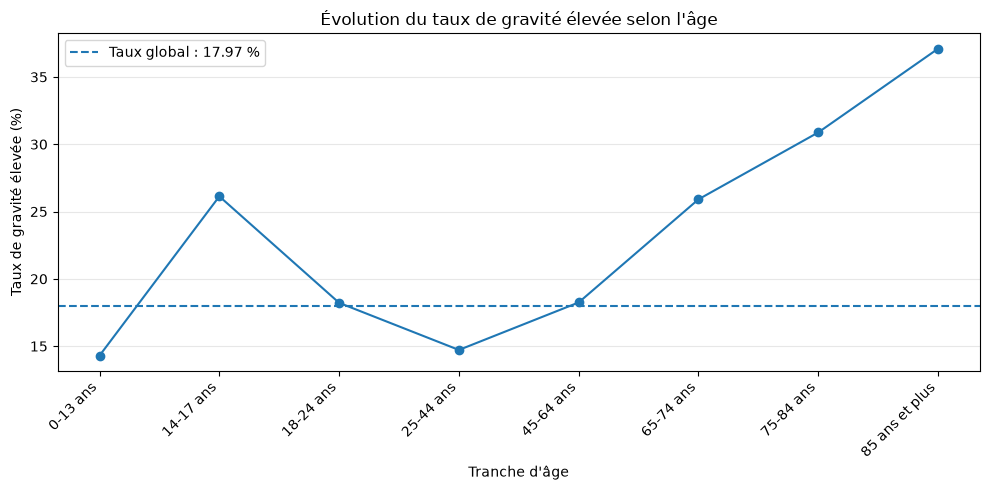

In [1574]:
# 4.10. Évolution du taux de gravité élevée selon l'âge

plt.figure(figsize=(10, 5))

plt.plot(
    gravite_par_age.index,
    gravite_par_age["taux_gravite_elevee"],
    marker="o"
)

plt.axhline(
    y=taux_gravite_elevee,
    linestyle="--",
    label=f"Taux global : {taux_gravite_elevee:.2f} %"
)

plt.title("Évolution du taux de gravité élevée selon l'âge")
plt.xlabel("Tranche d'âge")
plt.ylabel("Taux de gravité élevée (%)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Résultat :** la gravité élevée augmente nettement à partir de 65 ans et atteint 37,10 % chez les 85 ans et plus. Les 14-17 ans présentent également un taux élevé (26,13 %).

In [1575]:
# 4.11. Taux de gravité élevée selon le sexe

gravite_par_sexe = (
    usagers_gravite_connue
    .groupby("sexe")["gravite_elevee"]
    .agg(["count", "sum", "mean"])
)

gravite_par_sexe["taux_gravite_elevee"] = (
    gravite_par_sexe["mean"] * 100
).round(2)

gravite_par_sexe.index = gravite_par_sexe.index.map({
    1: "Masculin",
    2: "Féminin"
})

gravite_par_sexe[
    ["count", "sum", "taux_gravite_elevee"]
]

,count,sum,taux_gravite_elevee
sexe,,,
Masculin,411362,79385,19.30
Féminin,190184,30519,16.05


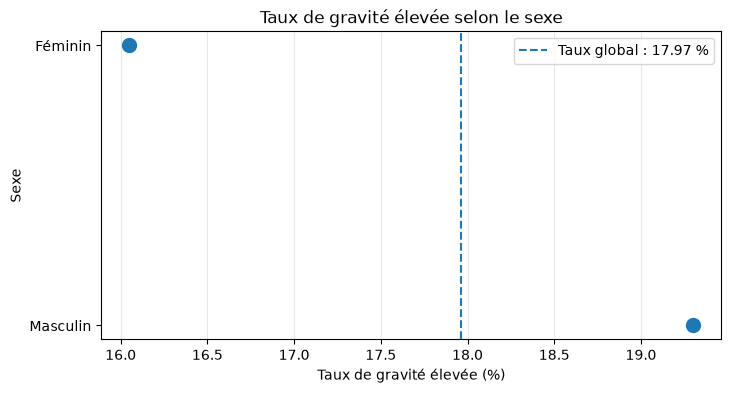

In [1576]:
# 4.12. Taux de gravité élevée selon le sexe

plt.figure(figsize=(8, 4))

plt.scatter(
    gravite_par_sexe["taux_gravite_elevee"],
    gravite_par_sexe.index,
    s=100
)

plt.axvline(
    x=taux_gravite_elevee,
    linestyle="--",
    label=f"Taux global : {taux_gravite_elevee:.2f} %"
)

plt.title("Taux de gravité élevée selon le sexe")
plt.xlabel("Taux de gravité élevée (%)")
plt.ylabel("Sexe")
plt.legend()
plt.grid(axis="x", alpha=0.3)

plt.show()

**Résultat :** le taux de gravité élevée est plus important chez les hommes (19,30 %) que chez les femmes (16,05 %). Les hommes se situent au-dessus du taux global de 17,97 %.

## 5. Gravité selon les circonstances de l'accident

In [1577]:
# 5.1. Association des usagers aux caractéristiques des accidents

usagers_circonstances = usagers_gravite_connue.merge(
    accidents[
        [
            "Num_Acc",
            "conditions_atmospheriques",
            "luminosite",
            "agglomeration"
        ]
    ],
    on="Num_Acc",
    how="left"
)

usagers_circonstances[
    [
        "gravite_elevee",
        "conditions_atmospheriques",
        "luminosite",
        "agglomeration"
    ]
].head()

,gravite_elevee,conditions_atmospheriques,luminosite,agglomeration
0,False,1.0,1.0,2
1,True,1.0,1.0,2
2,False,7.0,2.0,2
3,False,7.0,2.0,2
4,False,1.0,1.0,2


In [1578]:
# 5.2. Taux de gravité élevée selon les conditions atmosphériques

gravite_par_meteo = (
    usagers_circonstances
    .dropna(subset=["conditions_atmospheriques"])
    .groupby("conditions_atmospheriques")["gravite_elevee"]
    .agg(["count", "sum", "mean"])
)

gravite_par_meteo["taux_gravite_elevee"] = (
    gravite_par_meteo["mean"] * 100
).round(2)

gravite_par_meteo.index = gravite_par_meteo.index.map({
    1: "Normale",
    2: "Pluie légère",
    3: "Pluie forte",
    4: "Neige / grêle",
    5: "Brouillard / fumée",
    6: "Vent fort / tempête",
    7: "Temps éblouissant",
    8: "Temps couvert",
    9: "Autre"
})

gravite_par_meteo [["count", "sum", "taux_gravite_elevee"]
]

,count,sum,taux_gravite_elevee
conditions_atmospheriques,,,
Normale,484262,87250,18.02
Pluie légère,67657,10187,15.06
Pluie forte,14194,2581,18.18
Neige / grêle,2198,417,18.97
Brouillard / fumée,4515,1288,28.53
Vent fort / tempête,1710,505,29.53
Temps éblouissant,10806,2798,25.89
Temps couvert,23779,4192,17.63
Autre,2602,680,26.13


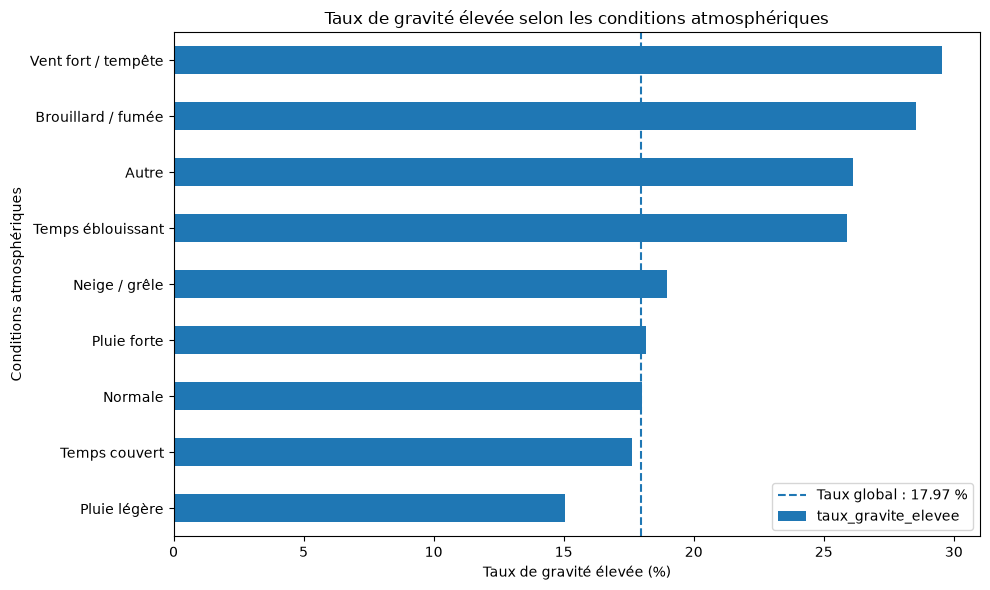

In [1579]:
# 5.3. Taux de gravité élevée selon les conditions atmosphériques

gravite_par_meteo_triee = gravite_par_meteo.sort_values(
    "taux_gravite_elevee"
)

gravite_par_meteo_triee["taux_gravite_elevee"].plot(
    kind="barh",
    figsize=(10, 6)
)

plt.axvline(
    x=taux_gravite_elevee,
    linestyle="--",
    label=f"Taux global : {taux_gravite_elevee:.2f} %"
)

plt.title("Taux de gravité élevée selon les conditions atmosphériques")
plt.xlabel("Taux de gravité élevée (%)")
plt.ylabel("Conditions atmosphériques")
plt.legend()

plt.tight_layout()
plt.show()

**Résultat :** les taux de gravité élevée sont particulièrement importants en cas de vent fort / tempête (29,53 %) et de brouillard / fumée (28,53 %). Ces situations concernent toutefois des effectifs beaucoup plus faibles que les conditions atmosphériques normales.

In [1580]:
# 5.4. Taux de gravité élevée selon la luminosité

gravite_par_luminosite = (
    usagers_circonstances
    .dropna(subset=["luminosite"])
    .groupby("luminosite")["gravite_elevee"]
    .agg(["count", "sum", "mean"])
)

gravite_par_luminosite["taux_gravite_elevee"] = (
    gravite_par_luminosite["mean"] * 100
).round(2)

gravite_par_luminosite.index = gravite_par_luminosite.index.map({
    1: "Plein jour",
    2: "Crépuscule / aube",
    3: "Nuit sans éclairage public",
    4: "Nuit avec éclairage public non allumé",
    5: "Nuit avec éclairage public allumé"
})

gravite_par_luminosite[
    ["count", "sum", "taux_gravite_elevee"]
]

,count,sum,taux_gravite_elevee
luminosite,,,
Plein jour,409030,69903,17.09
Crépuscule / aube,39681,8044,20.27
Nuit sans éclairage public,63371,17977,28.37
Nuit avec éclairage public non allumé,5955,1262,21.19
Nuit avec éclairage public allumé,93713,12716,13.57


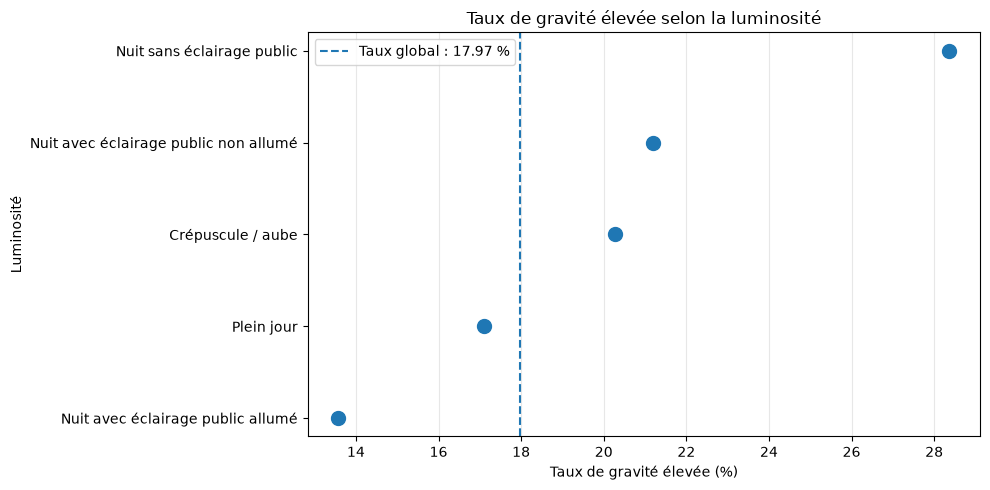

In [1581]:
# 5.5. Taux de gravité élevée selon la luminosité

gravite_par_luminosite_triee = gravite_par_luminosite.sort_values(
    "taux_gravite_elevee"
)

plt.figure(figsize=(10, 5))

plt.scatter(
    gravite_par_luminosite_triee["taux_gravite_elevee"],
    gravite_par_luminosite_triee.index,
    s=100
)

plt.axvline(
    x=taux_gravite_elevee,
    linestyle="--",
    label=f"Taux global : {taux_gravite_elevee:.2f} %"
)

plt.title("Taux de gravité élevée selon la luminosité")
plt.xlabel("Taux de gravité élevée (%)")
plt.ylabel("Luminosité")
plt.legend()
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

**Résultat :** la nuit sans éclairage public présente le taux de gravité élevée le plus important (28,37 %). À l'inverse, la nuit avec éclairage public allumé présente le taux le plus faible (13,57 %).

In [1582]:
# 5.6. Taux de gravité élevée selon l'agglomération

gravite_par_agglomeration = (
    usagers_circonstances
    .dropna(subset=["agglomeration"])
    .groupby("agglomeration")["gravite_elevee"]
    .agg(["count", "sum", "mean"])
)

gravite_par_agglomeration["taux_gravite_elevee"] = (
    gravite_par_agglomeration["mean"] * 100
).round(2)

gravite_par_agglomeration.index = gravite_par_agglomeration.index.map({
    1: "Hors agglomération",
    2: "En agglomération"
})

gravite_par_agglomeration[
    ["count", "sum", "taux_gravite_elevee"]
]

,count,sum,taux_gravite_elevee
agglomeration,,,
Hors agglomération,236151,60883,25.78
En agglomération,375611,49021,13.05


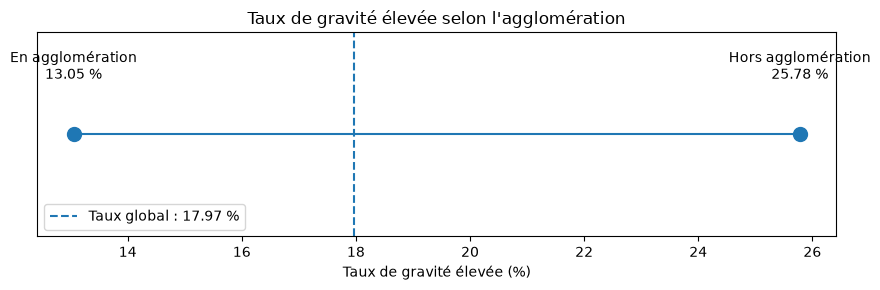

In [1583]:
# 5.7. Comparaison du taux de gravité élevée selon l'agglomération

taux_hors = gravite_par_agglomeration.loc[
    "Hors agglomération",
    "taux_gravite_elevee"
]

taux_en = gravite_par_agglomeration.loc[
    "En agglomération",
    "taux_gravite_elevee"
]

plt.figure(figsize=(9, 3))

plt.plot(
    [taux_en, taux_hors],
    [0, 0],
    marker="o",
    markersize=10
)

plt.axvline(
    x=taux_gravite_elevee,
    linestyle="--",
    label=f"Taux global : {taux_gravite_elevee:.2f} %"
)

plt.text(taux_en, 0.03, f"En agglomération\n{taux_en:.2f} %", ha="center")
plt.text(taux_hors, 0.03, f"Hors agglomération\n{taux_hors:.2f} %", ha="center")

plt.title("Taux de gravité élevée selon l'agglomération")
plt.xlabel("Taux de gravité élevée (%)")
plt.yticks([])
plt.legend()

plt.tight_layout()
plt.show()

**Résultat :** le taux de gravité élevée est nettement plus important hors agglomération (25,78 %) qu'en agglomération (13,05 %).

In [1584]:
# 5.8. Taux de gravité élevée selon le type de collision

gravite_par_collision = (
    usagers_gravite_connue
    .merge(
        accidents[["Num_Acc", "type_collision"]],
        on="Num_Acc",
        how="left"
    )
    .dropna(subset=["type_collision"])
    .groupby("type_collision")["gravite_elevee"]
    .agg(["count", "sum", "mean"])
)

gravite_par_collision["taux_gravite_elevee"] = (
    gravite_par_collision["mean"] * 100
).round(2)

gravite_par_collision.index = gravite_par_collision.index.map({
    1: "Deux véhicules - frontale",
    2: "Deux véhicules - par l'arrière",
    3: "Deux véhicules - par le côté",
    4: "Trois véhicules et plus - en chaîne",
    5: "Trois véhicules et plus - collisions multiples",
    6: "Autre collision",
    7: "Sans collision"
})

gravite_par_collision[
    ["count", "sum", "taux_gravite_elevee"]
]

,count,sum,taux_gravite_elevee
type_collision,,,
Deux véhicules - frontale,71424,19218,26.91
Deux véhicules - par l'arrière,88039,8384,9.52
Deux véhicules - par le côté,192917,24579,12.74
Trois véhicules et plus - en chaîne,39529,1883,4.76
Trois véhicules et plus - collisions multiples,32111,4243,13.21
Autre collision,145942,37092,25.42
Sans collision,37891,13929,36.76


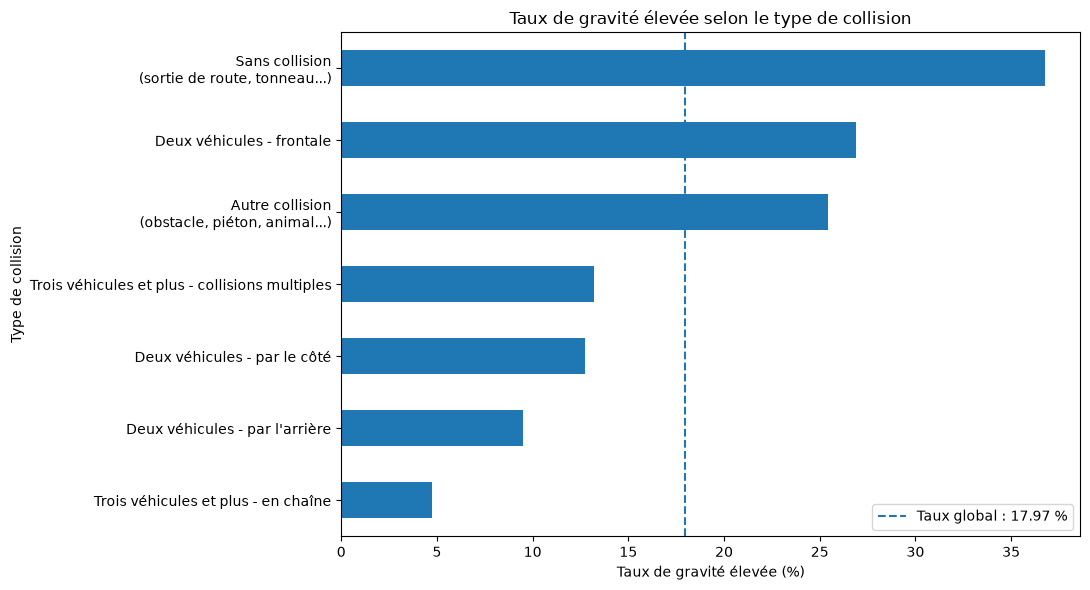

In [1585]:
# 5.9. Taux de gravité élevée selon le type de collision

collision_plot = (
    gravite_par_collision["taux_gravite_elevee"]
    .sort_values()
    .copy()
)

collision_plot = collision_plot.rename(index={
    "Autre collision": "Autre collision\n(obstacle, piéton, animal...)",
    "Sans collision": "Sans collision\n(sortie de route, tonneau...)"
})

plt.figure(figsize=(11, 6))

collision_plot.plot(
    kind="barh",
    legend=False
)

ligne_taux_global = plt.axvline(
    x=taux_gravite_elevee,
    linestyle="--",
    label=f"Taux global : {taux_gravite_elevee:.2f} %"
)

plt.title("Taux de gravité élevée selon le type de collision")
plt.xlabel("Taux de gravité élevée (%)")
plt.ylabel("Type de collision")

plt.legend(handles=[ligne_taux_global])

plt.tight_layout()
plt.show()

**Résultat :** les accidents sans collision présentent le taux de gravité élevée le plus important (36,76 %), suivis des collisions frontales (26,91 %) et des autres collisions (25,42 %). Ces trois catégories se situent au-dessus du taux global de 17,97 %.

### 5.10. Gravité selon la famille de véhicule

Les catégories de véhicules du BAAC sont regroupées en grandes familles afin de faciliter l'analyse et la visualisation. Ce regroupement analytique est construit à partir de la nomenclature officielle BAAC.

La gravité étant renseignée au niveau de l'usager, les données des usagers et des véhicules sont reliées grâce à `id_vehicule`. Les véhicules de catégorie indéterminable sont exclus de cette analyse.

In [1586]:
# 5.10. Taux de gravité élevée selon la famille de véhicule

usagers_vehicules = usagers_gravite_connue.merge(
    vehicules[["id_vehicule", "categorie_vehicule"]],
    on="id_vehicule",
    how="left"
)

def regrouper_vehicule(code):
    if code in [1, 80]:
        return "Vélo / VAE"
    elif code in [2, 30, 31, 32, 33, 34]:
        return "Deux-roues motorisés"
    elif code in [35, 36, 41, 42, 43]:
        return "Trois-roues / Quads"
    elif code == 7:
        return "Voiture"
    elif code == 10:
        return "Utilitaire"
    elif code in [13, 14, 15, 16, 17]:
        return "Poids lourd"
    elif code in [37, 38]:
        return "Transport en commun"
    elif code in [50, 60]:
        return "EDP"
    elif code in [20, 21]:
        return "Engins spéciaux / agricoles"
    elif code in [39, 40]:
        return "Train / Tramway"
    elif code in [3, 99]:
        return "Autre véhicule"
    elif code == 0:
        return "Indéterminable"

usagers_vehicules["famille_vehicule"] = (
    usagers_vehicules["categorie_vehicule"]
    .apply(regrouper_vehicule)
)

gravite_par_vehicule = (
    usagers_vehicules
    .dropna(subset=["famille_vehicule"])
    .query("famille_vehicule != 'Indéterminable'")
    .groupby("famille_vehicule")["gravite_elevee"]
    .agg(["count", "sum", "mean"])
)

gravite_par_vehicule["taux_gravite_elevee"] = (
    gravite_par_vehicule["mean"] * 100
).round(2)

gravite_par_vehicule[
    ["count", "sum", "taux_gravite_elevee"]
].sort_values(
    "taux_gravite_elevee",
    ascending=False
)

,count,sum,taux_gravite_elevee
famille_vehicule,,,
Deux-roues motorisés,102616,35270,34.37
Trois-roues / Quads,4737,1419,29.96
Vélo / VAE,31125,8276,26.59
Engins spéciaux / agricoles,1968,351,17.84
Autre véhicule,6036,1067,17.68
EDP,12355,2061,16.68
Voiture,383744,54545,14.21
Train / Tramway,1230,161,13.09
Utilitaire,43432,4522,10.41


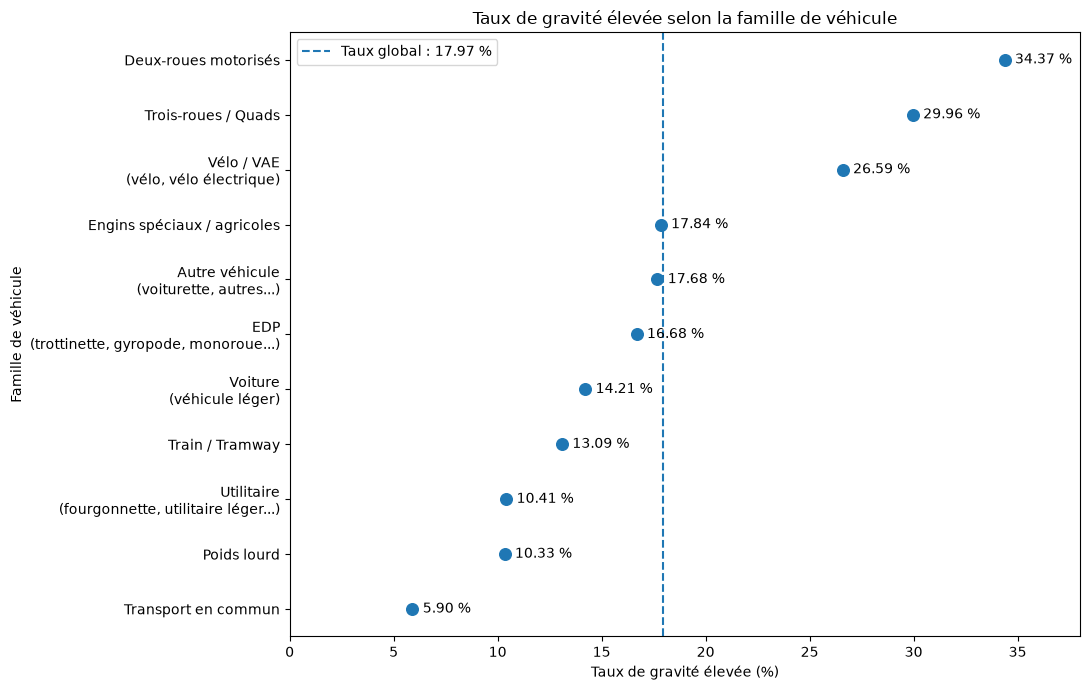

In [1587]:
# 5.11. Taux de gravité élevée selon la famille de véhicule

vehicule_plot = (
    gravite_par_vehicule["taux_gravite_elevee"]
    .sort_values()
    .copy()
)

vehicule_plot = vehicule_plot.rename(index={
    "Vélo / VAE": "Vélo / VAE\n(vélo, vélo électrique)",
    "EDP": "EDP\n(trottinette, gyropode, monoroue...)",
    "Voiture": "Voiture\n(véhicule léger)",
    "Utilitaire": "Utilitaire\n(fourgonnette, utilitaire léger...)",
    "Autre véhicule": "Autre véhicule\n(voiturette, autres...)"
})

plt.figure(figsize=(11, 7))

plt.scatter(
    vehicule_plot.values,
    vehicule_plot.index,
    s=70
)

plt.axvline(
    x=taux_gravite_elevee,
    linestyle="--",
    label=f"Taux global : {taux_gravite_elevee:.2f} %"
)

for famille, taux in vehicule_plot.items():
    plt.text(
        taux + 0.5,
        famille,
        f"{taux:.2f} %",
        va="center"
    )

plt.title("Taux de gravité élevée selon la famille de véhicule")
plt.xlabel("Taux de gravité élevée (%)")
plt.ylabel("Famille de véhicule")

plt.xlim(0, 38)

plt.legend()

plt.tight_layout()
plt.show()

**Résultat :** les taux de gravité élevée les plus importants concernent les deux-roues motorisés (34,37 %), les trois-roues / quads (29,96 %) et les vélos / VAE (26,59 %), nettement au-dessus du taux global de 17,97 %.

## 6. Analyse géographique des accidents et de leur gravité par territoire

Cette partie analyse la répartition géographique des accidents et identifie les territoires où les accidents graves sont les plus fréquents.

In [1588]:
# 6.1. Gravité élevée par code géographique

usagers_territoires = usagers_gravite_connue.merge(
    accidents[["Num_Acc", "departement"]],
    on="Num_Acc",
    how="left"
)

usagers_territoires = usagers_territoires.rename(
    columns={"departement": "code_geographique"}
)

gravite_par_territoire = (
    usagers_territoires
    .dropna(subset=["code_geographique"])
    .groupby("code_geographique")["gravite_elevee"]
    .agg(["count", "sum", "mean"])
)

gravite_par_territoire["taux_gravite_elevee"] = (
    gravite_par_territoire["mean"] * 100
).round(2)

gravite_par_territoire[
    ["count", "sum", "taux_gravite_elevee"]
].sort_values(
    "sum",
    ascending=False
).head(10)

,count,sum,taux_gravite_elevee
code_geographique,,,
13,28510,4043,14.18
83,9630,2605,27.05
59,11265,2582,22.92
69,24024,2563,10.67
33,15288,2412,15.78
34,7512,2241,29.83
38,7473,2069,27.69
75,51337,1989,3.87
62,6165,1987,32.23


In [1589]:
# 6.2. Chargement du référentiel des départements

departements = pd.read_csv(
    "data/referentiels/v_departement_2024.csv",
    dtype={"DEP": str}
)

departements = departements[
    ["DEP", "REG", "LIBELLE"]
]

departements.head()

,DEP,REG,LIBELLE
0,01,84,Ain
1,02,32,Aisne
2,03,84,Allier
3,04,93,Alpes-de-Haute-Provence
4,05,93,Hautes-Alpes


In [1590]:
# 6.3. Chargement du référentiel des collectivités et territoires d'outre-mer

territoires_outre_mer = pd.read_csv(
    "data/referentiels/v_comer_2024.csv",
    dtype={"COMER": str}
)

territoires_outre_mer = territoires_outre_mer[
    ["COMER", "LIBELLE"]
]

territoires_outre_mer

,COMER,LIBELLE
0,975,Saint-Pierre-et-Miquelon
1,977,Saint-Barthélemy
2,978,Saint-Martin
3,984,Terres australes et antarctiques françaises
4,986,Wallis-et-Futuna
5,987,Polynésie française
6,988,Nouvelle-Calédonie
7,989,La Passion-Clipperton


In [1591]:
# 6.4. Création du référentiel géographique unique

referentiel_departements = departements[
    ["DEP", "LIBELLE"]
].rename(
    columns={"DEP": "code_geographique"}
)

referentiel_outre_mer = territoires_outre_mer[
    ["COMER", "LIBELLE"]
].rename(
    columns={"COMER": "code_geographique"}
)

referentiel_geographique = pd.concat(
    [referentiel_departements, referentiel_outre_mer],
    ignore_index=True
)

referentiel_geographique

,code_geographique,LIBELLE
0,01,Ain
1,02,Aisne
2,03,Allier
3,04,Alpes-de-Haute-Provence
4,05,Hautes-Alpes
...,...,...
104,984,Terres australes et antarctiques françaises
105,986,Wallis-et-Futuna
106,987,Polynésie française
107,988,Nouvelle-Calédonie


In [1592]:
# 6.5. Ajout des noms des territoires

gravite_par_territoire_noms = (
    gravite_par_territoire
    .reset_index()
)

gravite_par_territoire_noms["code_geographique"] = (
    gravite_par_territoire_noms["code_geographique"]
    .astype(str)
    .str.zfill(2)
)

gravite_par_territoire_noms = gravite_par_territoire_noms.merge(
    referentiel_geographique,
    on="code_geographique",
    how="left"
)

gravite_par_territoire_noms[
    ["code_geographique", "LIBELLE", "count", "sum", "taux_gravite_elevee"]
].sort_values(
    "sum",
    ascending=False
).head(10)

,code_geographique,LIBELLE,count,sum,taux_gravite_elevee
12,13,Bouches-du-Rhône,28510,4043,14.18
83,83,Var,9630,2605,27.05
59,59,Nord,11265,2582,22.92
69,69,Rhône,24024,2563,10.67
33,33,Gironde,15288,2412,15.78
34,34,Hérault,7512,2241,29.83
38,38,Isère,7473,2069,27.69
75,75,Paris,51337,1989,3.87
62,62,Pas-de-Calais,6165,1987,32.23
5,06,Alpes-Maritimes,9374,1940,20.70


In [1593]:
# 6.6. Vérification des correspondances géographiques

gravite_par_territoire_noms[
    gravite_par_territoire_noms["LIBELLE"].isna()
]

,code_geographique,count,sum,mean,taux_gravite_elevee,LIBELLE


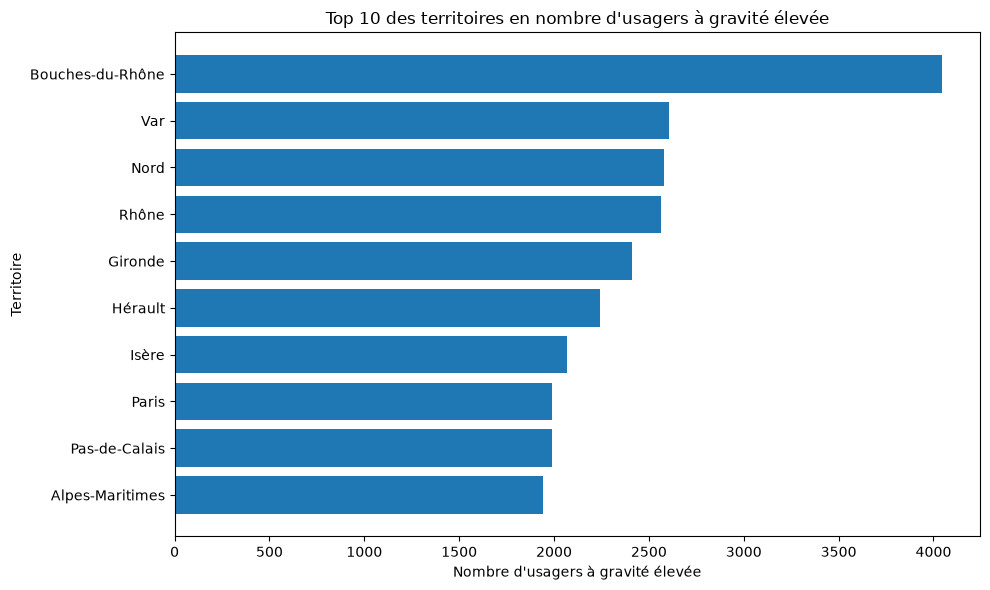

In [1594]:
# 6.7. Top 10 des territoires en nombre d'usagers à gravité élevée

top10_territoires_volume = (
    gravite_par_territoire_noms
    .sort_values("sum", ascending=False)
    .head(10)
    .sort_values("sum")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_territoires_volume["LIBELLE"],
    top10_territoires_volume["sum"]
)

plt.title("Top 10 des territoires en nombre d'usagers à gravité élevée")
plt.xlabel("Nombre d'usagers à gravité élevée")
plt.ylabel("Territoire")

plt.tight_layout()
plt.show()

**Résultat :** les Bouches-du-Rhône concentrent le plus grand nombre d'usagers à gravité élevée (4 043), devant le Var (2 605) et le Nord (2 582). Ce classement représente un volume et ne tient pas compte du nombre total d'usagers impliqués dans chaque territoire.

In [1595]:
# 6.8. Territoires avec les taux de gravité élevée les plus importants

gravite_par_territoire_noms[
    ["code_geographique", "LIBELLE", "count", "sum", "taux_gravite_elevee"]
].sort_values(
    "taux_gravite_elevee",
    ascending=False
).head(10)

,code_geographique,LIBELLE,count,sum,taux_gravite_elevee
104,986,Wallis-et-Futuna,102,50,49.02
102,977,Saint-Barthélemy,127,60,47.24
70,70,Haute-Saône,1125,501,44.53
103,978,Saint-Martin,346,150,43.35
53,53,Mayenne,1338,574,42.90
22,24,Dordogne,2142,909,42.44
15,16,Charente,1455,617,42.41
105,987,Polynésie française,1897,793,41.80
21,23,Creuse,495,204,41.21
40,40,Landes,1939,795,41.00


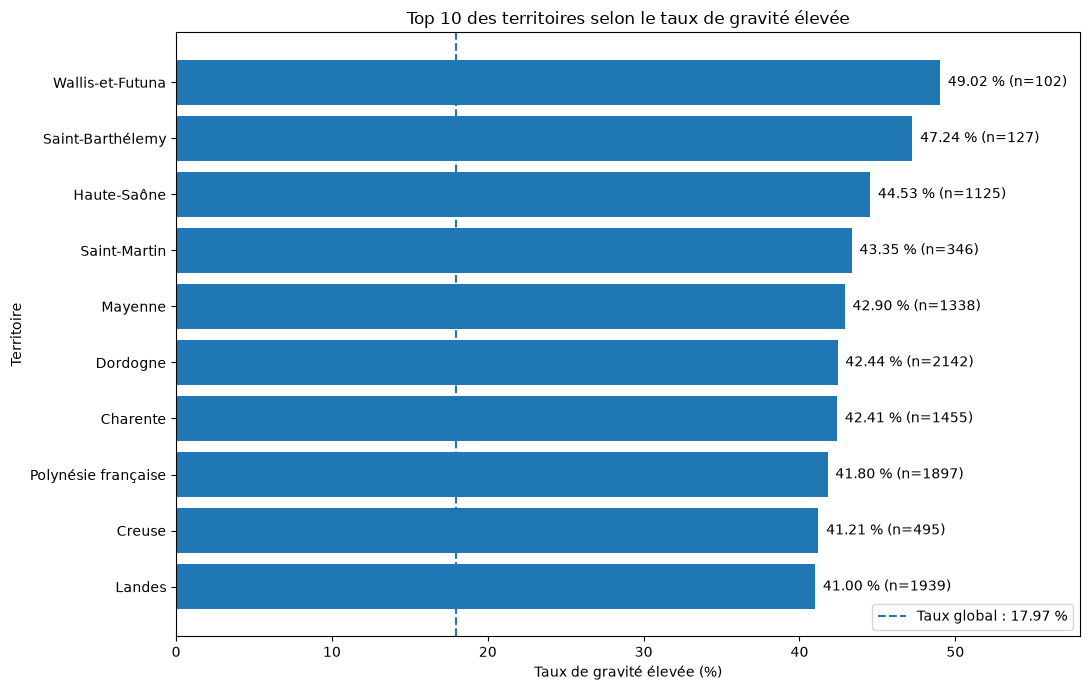

In [1596]:
# 6.9. Top 10 des territoires selon le taux de gravité élevée

top10_territoires_taux = (
    gravite_par_territoire_noms
    .sort_values("taux_gravite_elevee", ascending=False)
    .head(10)
    .sort_values("taux_gravite_elevee")
)

plt.figure(figsize=(11, 7))

plt.barh(
    top10_territoires_taux["LIBELLE"],
    top10_territoires_taux["taux_gravite_elevee"]
)

plt.axvline(
    x=taux_gravite_elevee,
    linestyle="--",
    label=f"Taux global : {taux_gravite_elevee:.2f} %"
)

for _, ligne in top10_territoires_taux.iterrows():
    plt.text(
        ligne["taux_gravite_elevee"] + 0.5,
        ligne["LIBELLE"],
        f'{ligne["taux_gravite_elevee"]:.2f} % (n={ligne["count"]})',
        va="center"
    )

plt.title("Top 10 des territoires selon le taux de gravité élevée")
plt.xlabel("Taux de gravité élevée (%)")
plt.ylabel("Territoire")

plt.xlim(0, 58)

plt.legend()

plt.tight_layout()
plt.show()

**Résultat :** les taux de gravité élevée les plus importants sont observés à Wallis-et-Futuna (49,02 %) et Saint-Barthélemy (47,24 %). Ces résultats doivent toutefois être interprétés avec prudence en raison de leurs faibles effectifs ; plusieurs départements comme la Haute-Saône, la Mayenne ou la Dordogne présentent également des taux supérieurs à 40 % avec des effectifs plus importants.

## 7. Analyse des caractéristiques de la route

La table `lieux` peut contenir plusieurs lignes pour un même accident. Une jointure directe avec les usagers pourrait donc dupliquer certaines observations et fausser les effectifs et les taux de gravité. Les variables routières seront analysées en tenant compte de cette particularité.

In [1597]:
# 7.1. Variables disponibles sur les lieux

lieux.columns.tolist()

['Num_Acc',
 'categorie_route',
 'regime_circulation',
 'nombre_voies',
 'profil_route',
 'trace_route',
 'etat_surface',
 'situation_accident',
 'vitesse_max_autorisee']

Pour éviter de dupliquer les usagers lors de la jointure avec `lieux`, les caractéristiques routières sont analysées au niveau de l'accident.

In [1598]:
# 7.2. Création de la gravité élevée au niveau de l'accident

gravite_par_accident = (
    usagers_gravite_connue[
        ["id_vehicule", "gravite_elevee"]
    ]
    .merge(
        vehicules[["id_vehicule", "Num_Acc"]],
        on="id_vehicule",
        how="left"
    )
    .groupby("Num_Acc")["gravite_elevee"]
    .max()
    .reset_index()
)

gravite_par_accident.head()

,Num_Acc,gravite_elevee
0,202000000001,True
1,202000000002,False
2,202000000003,True
3,202000000004,True
4,202000000005,False


Pour les variables routières, un même accident n'est compté qu'une fois par catégorie analysée afin d'éviter les doublons liés aux lignes multiples de `lieux`.

In [1599]:
# 7.3. Gravité élevée selon la catégorie de route

lieux_categorie_route = (
    lieux[
        ["Num_Acc", "categorie_route"]
    ]
    .dropna(subset=["categorie_route"])
    .drop_duplicates(
        subset=["Num_Acc", "categorie_route"]
    )
)

gravite_categorie_route = lieux_categorie_route.merge(
    gravite_par_accident,
    on="Num_Acc",
    how="inner"
)

gravite_par_categorie_route = (
    gravite_categorie_route
    .groupby("categorie_route")["gravite_elevee"]
    .agg(
        nombre_accidents="count",
        accidents_gravite_elevee="sum",
        taux_gravite_elevee="mean"
    )
)

gravite_par_categorie_route["taux_gravite_elevee"] = (
    gravite_par_categorie_route["taux_gravite_elevee"] * 100
).round(2)

gravite_par_categorie_route.sort_values(
    "taux_gravite_elevee",
    ascending=False
)

,nombre_accidents,accidents_gravite_elevee,taux_gravite_elevee
categorie_route,,,
3,101751,51484,50.60
5,310,154,49.68
9,1387,646,46.58
2,17268,7048,40.82
6,1970,772,39.19
7,8499,2970,34.95
4,112477,27218,24.20
1,25126,5846,23.27


In [1600]:
# 7.4. Ajout des libellés des catégories de route

libelles_categorie_route = {
    1: "Autoroute",
    2: "Route nationale",
    3: "Route départementale",
    4: "Voie communale",
    5: "Hors réseau public",
    6: "Parc de stationnement",
    7: "Route de métropole urbaine",
    9: "Autre"
}

gravite_par_categorie_route["libelle_route"] = (
    gravite_par_categorie_route.index
    .map(libelles_categorie_route)
)

gravite_par_categorie_route[
    [
        "libelle_route",
        "nombre_accidents",
        "accidents_gravite_elevee",
        "taux_gravite_elevee"
    ]
].sort_values(
    "taux_gravite_elevee",
    ascending=False
)

,libelle_route,nombre_accidents,accidents_gravite_elevee,taux_gravite_elevee
categorie_route,,,,
3,Route départementale,101751,51484,50.60
5,Hors réseau public,310,154,49.68
9,Autre,1387,646,46.58
2,Route nationale,17268,7048,40.82
6,Parc de stationnement,1970,772,39.19
7,Route de métropole urbaine,8499,2970,34.95
4,Voie communale,112477,27218,24.20
1,Autoroute,25126,5846,23.27


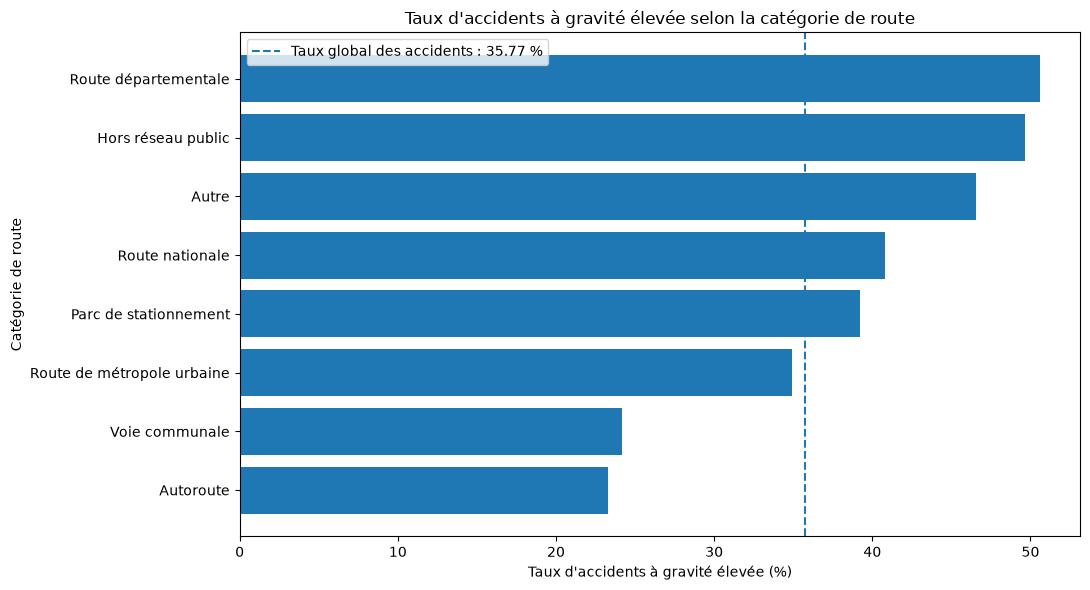

In [1601]:
# 7.5. Taux de gravité élevée selon la catégorie de route

taux_global_accidents = (
    gravite_par_accident["gravite_elevee"].mean() * 100
)

categorie_route_plot = (
    gravite_par_categorie_route
    .sort_values("taux_gravite_elevee")
)

plt.figure(figsize=(11, 6))

plt.barh(
    categorie_route_plot["libelle_route"],
    categorie_route_plot["taux_gravite_elevee"]
)

plt.axvline(
    x=taux_global_accidents,
    linestyle="--",
    label=f"Taux global des accidents : {taux_global_accidents:.2f} %"
)

plt.title("Taux d'accidents à gravité élevée selon la catégorie de route")
plt.xlabel("Taux d'accidents à gravité élevée (%)")
plt.ylabel("Catégorie de route")

plt.legend()

plt.tight_layout()
plt.show()

**Résultat :** la gravité des accidents varie fortement selon la catégorie de route. Les routes départementales présentent le taux le plus élevé (50,60 %), devant les routes nationales (40,82 %), tandis que les autoroutes et les voies communales présentent des taux inférieurs au taux global des accidents (35,77 %).

In [1602]:
# 7.6. Gravité élevée selon l'état de la surface

lieux_etat_surface = (
    lieux[
        ["Num_Acc", "etat_surface"]
    ]
    .dropna(subset=["etat_surface"])
    .drop_duplicates(
        subset=["Num_Acc", "etat_surface"]
    )
)

gravite_etat_surface = lieux_etat_surface.merge(
    gravite_par_accident,
    on="Num_Acc",
    how="inner"
)

gravite_par_etat_surface = (
    gravite_etat_surface
    .groupby("etat_surface")["gravite_elevee"]
    .agg(
        nombre_accidents="count",
        accidents_gravite_elevee="sum",
        taux_gravite_elevee="mean"
    )
)

gravite_par_etat_surface["taux_gravite_elevee"] = (
    gravite_par_etat_surface["taux_gravite_elevee"] * 100
).round(2)

gravite_par_etat_surface.sort_values(
    "taux_gravite_elevee",
    ascending=False
)

,nombre_accidents,accidents_gravite_elevee,taux_gravite_elevee
etat_surface,,,
6.0,240,153,63.75
9.0,1485,838,56.43
7.0,978,489,50.00
5.0,404,176,43.56
4.0,139,58,41.73
8.0,413,158,38.26
1.0,215028,77955,36.25
3.0,437,156,35.70
2.0,49914,16248,32.55


In [1603]:
# 7.7. Ajout des libellés de l'état de la surface

libelles_etat_surface = {
    1: "Normale",
    2: "Mouillée",
    3: "Flaques",
    4: "Inondée",
    5: "Enneigée",
    6: "Boue",
    7: "Verglacée",
    8: "Corps gras / huile",
    9: "Autre"
}

gravite_par_etat_surface["libelle_surface"] = (
    gravite_par_etat_surface.index
    .map(libelles_etat_surface)
)

gravite_par_etat_surface[
    [
        "libelle_surface",
        "nombre_accidents",
        "accidents_gravite_elevee",
        "taux_gravite_elevee"
    ]
].sort_values(
    "taux_gravite_elevee",
    ascending=False
)

,libelle_surface,nombre_accidents,accidents_gravite_elevee,taux_gravite_elevee
etat_surface,,,,
6.0,Boue,240,153,63.75
9.0,Autre,1485,838,56.43
7.0,Verglacée,978,489,50.00
5.0,Enneigée,404,176,43.56
4.0,Inondée,139,58,41.73
8.0,Corps gras / huile,413,158,38.26
1.0,Normale,215028,77955,36.25
3.0,Flaques,437,156,35.70
2.0,Mouillée,49914,16248,32.55


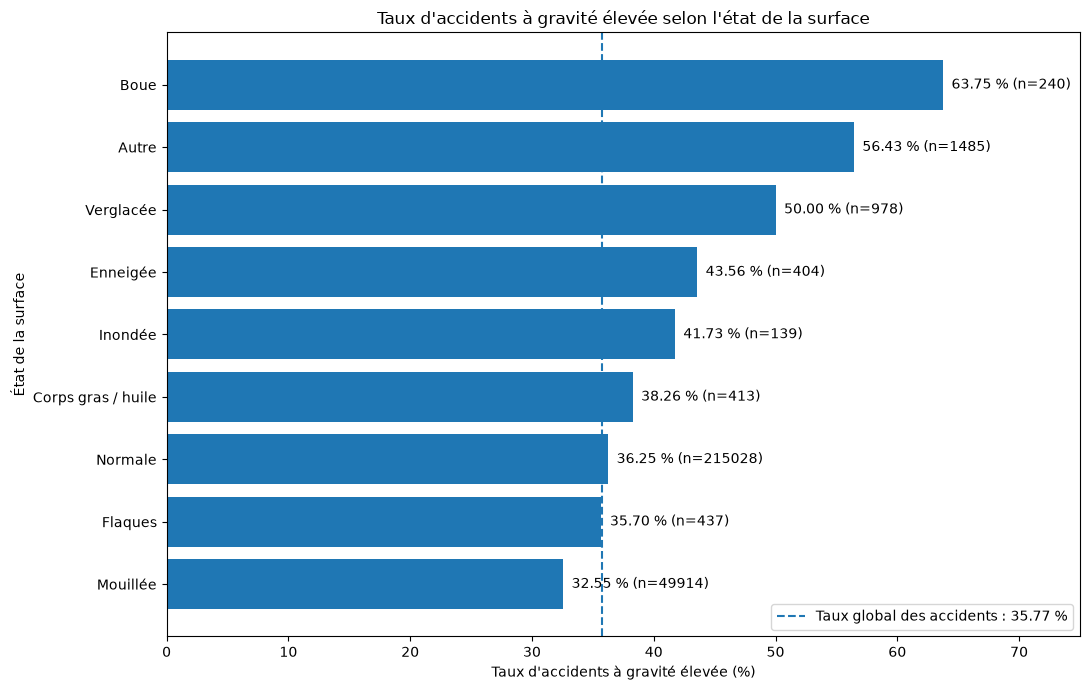

In [1604]:
# 7.8. Taux de gravité élevée selon l'état de la surface

surface_plot = (
    gravite_par_etat_surface
    .sort_values("taux_gravite_elevee")
)

plt.figure(figsize=(11, 7))

plt.barh(
    surface_plot["libelle_surface"],
    surface_plot["taux_gravite_elevee"]
)

plt.axvline(
    x=taux_global_accidents,
    linestyle="--",
    label=f"Taux global des accidents : {taux_global_accidents:.2f} %"
)

for _, ligne in surface_plot.iterrows():
    plt.text(
        ligne["taux_gravite_elevee"] + 0.7,
        ligne["libelle_surface"],
        f'{ligne["taux_gravite_elevee"]:.2f} % (n={ligne["nombre_accidents"]})',
        va="center"
    )

plt.title("Taux d'accidents à gravité élevée selon l'état de la surface")
plt.xlabel("Taux d'accidents à gravité élevée (%)")
plt.ylabel("État de la surface")

plt.xlim(0, 75)

plt.legend()

plt.tight_layout()
plt.show()

**Résultat :** certaines surfaces particulières, notamment la boue et le verglas, présentent des taux de gravité élevée supérieurs au taux global, mais concernent peu d'accidents. Les accidents surviennent principalement sur des surfaces normales ou mouillées, dont les taux sont proches ou inférieurs au taux global.

In [1605]:
# 7.9. Gravité élevée selon la vitesse maximale autorisée

lieux_vitesse = (
    lieux[
        ["Num_Acc", "vitesse_max_autorisee"]
    ]
    .dropna(subset=["vitesse_max_autorisee"])
    .query("vitesse_max_autorisee > 0")
    .drop_duplicates(
        subset=["Num_Acc", "vitesse_max_autorisee"]
    )
)

gravite_vitesse = lieux_vitesse.merge(
    gravite_par_accident,
    on="Num_Acc",
    how="inner"
)

gravite_par_vitesse = (
    gravite_vitesse
    .groupby("vitesse_max_autorisee")["gravite_elevee"]
    .agg(
        nombre_accidents="count",
        accidents_gravite_elevee="sum",
        taux_gravite_elevee="mean"
    )
)

gravite_par_vitesse["taux_gravite_elevee"] = (
    gravite_par_vitesse["taux_gravite_elevee"] * 100
).round(2)

gravite_par_vitesse

,nombre_accidents,accidents_gravite_elevee,taux_gravite_elevee
vitesse_max_autorisee,,,
1.0,72,14,19.44
2.0,39,8,20.51
3.0,14,2,14.29
4.0,3,1,33.33
5.0,115,27,23.48
6.0,27,4,14.81
7.0,2,1,50.00
8.0,2,0,0.00
9.0,1,0,0.00


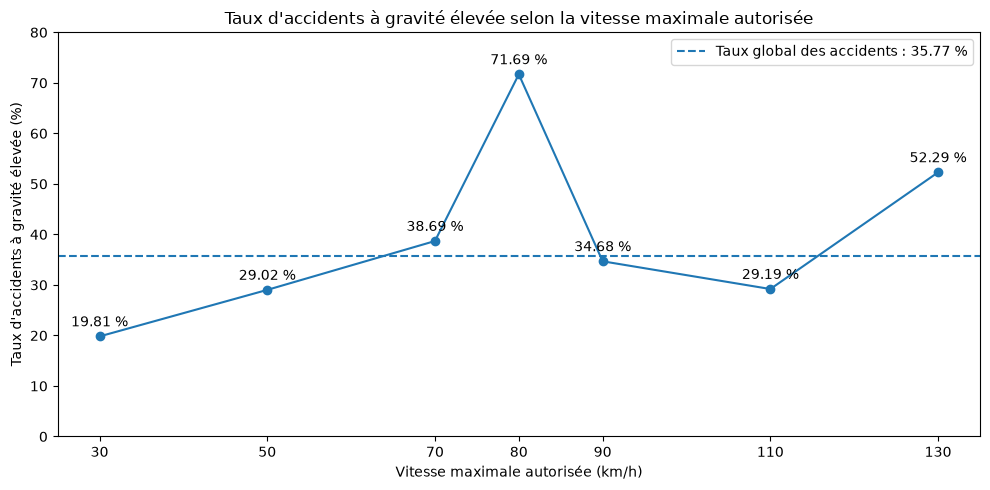

In [1606]:
# 7.10. Taux de gravité élevée selon les principales limitations de vitesse

vitesses_principales = [30, 50, 70, 80, 90, 110, 130]

vitesse_plot = (
    gravite_par_vitesse
    .loc[vitesses_principales]
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    vitesse_plot["vitesse_max_autorisee"],
    vitesse_plot["taux_gravite_elevee"],
    marker="o"
)

plt.axhline(
    y=taux_global_accidents,
    linestyle="--",
    label=f"Taux global des accidents : {taux_global_accidents:.2f} %"
)

for _, ligne in vitesse_plot.iterrows():
    plt.text(
        ligne["vitesse_max_autorisee"],
        ligne["taux_gravite_elevee"] + 2,
        f'{ligne["taux_gravite_elevee"]:.2f} %',
        ha="center"
    )

plt.title("Taux d'accidents à gravité élevée selon la vitesse maximale autorisée")
plt.xlabel("Vitesse maximale autorisée (km/h)")
plt.ylabel("Taux d'accidents à gravité élevée (%)")

plt.xticks(vitesses_principales)
plt.ylim(0, 80)

plt.legend()

plt.tight_layout()
plt.show()

**Résultat :** la gravité ne progresse pas régulièrement avec la vitesse maximale autorisée. Les accidents associés aux limitations de 80 km/h (71,69 %) et 130 km/h (52,29 %) présentent les taux les plus élevés parmi les principales limitations étudiées. Ces résultats montrent une association avec le contexte routier, sans permettre d'établir un effet causal de la vitesse.

## 8. Analyse statistique des facteurs associés à la gravité

In [1607]:
# 8.1. Tableau de contingence entre catégorie d'usager et gravité

table_categorie_usager = pd.crosstab(
    usagers_gravite_connue["categorie_usager"],
    usagers_gravite_connue["gravite_elevee"]
)

table_categorie_usager

gravite_elevee,False,True
categorie_usager,,
1,379069,76429
2,91674,18345
3,31115,15130


In [1608]:
# 8.2. Test du Chi² entre catégorie d'usager et gravité

from scipy.stats import chi2_contingency

chi2, p_value, ddl, effectifs_attendus = chi2_contingency(
    table_categorie_usager
)

print(f"Chi² : {chi2:.2f}")
print(f"p-value : {p_value:.6f}")
print(f"Degrés de liberté : {ddl}")

Chi² : 7387.66
p-value : 0.000000
Degrés de liberté : 2


**Résultat :** la p-value est inférieure à 0,05. L'hypothèse d'indépendance (H₀) est donc rejetée : il existe une association statistiquement significative entre la catégorie d'usager et la gravité élevée. Le test du Chi² ne permet toutefois pas de mesurer la force de cette association.

In [1609]:
# 8.3. Calcul du V de Cramér entre catégorie d'usager et gravité

n = table_categorie_usager.to_numpy().sum()

v_cramer = np.sqrt(
    chi2 / (
        n * min(
            table_categorie_usager.shape[0] - 1,
            table_categorie_usager.shape[1] - 1
        )
    )
)

print(f"V de Cramér : {v_cramer:.3f}")

V de Cramér : 0.110


**Résultat :** l'association entre la catégorie d'usager et la gravité élevée est statistiquement significative, mais son intensité reste faible (V de Cramér = 0,110).

In [1610]:
# 8.4. Fonction de calcul du Chi² et du V de Cramér

def calculer_association(data, variable, cible="gravite_elevee"):

    donnees = data[
        [variable, cible]
    ].dropna()

    tableau = pd.crosstab(
        donnees[variable],
        donnees[cible]
    )

    chi2, p_value, ddl, effectifs_attendus = chi2_contingency(
        tableau
    )

    n = tableau.to_numpy().sum()

    v_cramer = np.sqrt(
        chi2 / (
            n * min(
                tableau.shape[0] - 1,
                tableau.shape[1] - 1
            )
        )
    )

    return {
        "facteur": variable,
        "nombre_observations": n,
        "chi2": round(chi2, 2),
        "p_value": p_value,
        "v_cramer": round(v_cramer, 3)
    }

In [1611]:
# 8.5. Comparaison statistique des principaux facteurs associés à la gravité

resultats_associations = [
    calculer_association(
        usagers_gravite_connue,
        "categorie_usager"
    ),
    calculer_association(
        usagers_gravite_connue,
        "sexe"
    ),
    calculer_association(
        usagers_age_analyse,
        "tranche_age"
    ),
    calculer_association(
        usagers_circonstances,
        "conditions_atmospheriques"
    ),
    calculer_association(
        usagers_circonstances,
        "luminosite"
    ),
    calculer_association(
        usagers_circonstances,
        "agglomeration"
    ),
    calculer_association(
        usagers_vehicules,
        "famille_vehicule"
    )
]

comparaison_associations = pd.DataFrame(
    resultats_associations
)

comparaison_associations = comparaison_associations.sort_values(
    "v_cramer",
    ascending=False
)

comparaison_associations

,facteur,nombre_observations,chi2,p_value,v_cramer
6,famille_vehicule,611743,27578.49,0.000000e+00,0.212
5,agglomeration,611762,15943.21,0.000000e+00,0.161
2,tranche_age,601018,8891.09,0.000000e+00,0.122
0,categorie_usager,611762,7387.66,0.000000e+00,0.110
4,luminosite,611750,6279.98,0.000000e+00,0.101
3,conditions_atmospheriques,611723,1468.62,8.221817e-312,0.049
1,sexe,601546,920.31,3.770623e-202,0.039


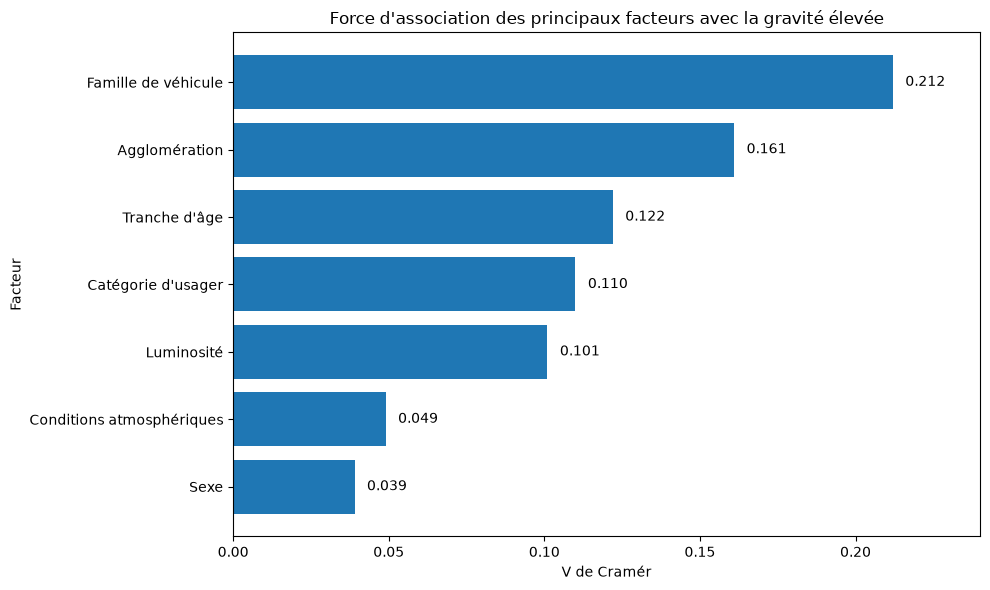

In [1612]:
# 8.6. Comparaison de la force d'association des facteurs avec la gravité

associations_plot = (
    comparaison_associations
    .sort_values("v_cramer")
    .copy()
)

libelles_facteurs = {
    "famille_vehicule": "Famille de véhicule",
    "agglomeration": "Agglomération",
    "tranche_age": "Tranche d'âge",
    "categorie_usager": "Catégorie d'usager",
    "luminosite": "Luminosité",
    "conditions_atmospheriques": "Conditions atmosphériques",
    "sexe": "Sexe"
}

associations_plot["facteur"] = (
    associations_plot["facteur"]
    .replace(libelles_facteurs)
)

plt.figure(figsize=(10, 6))

plt.barh(
    associations_plot["facteur"],
    associations_plot["v_cramer"]
)

for _, ligne in associations_plot.iterrows():
    plt.text(
        ligne["v_cramer"] + 0.004,
        ligne["facteur"],
        f'{ligne["v_cramer"]:.3f}',
        va="center"
    )

plt.title("Force d'association des principaux facteurs avec la gravité élevée")
plt.xlabel("V de Cramér")
plt.ylabel("Facteur")

plt.xlim(0, 0.24)

plt.tight_layout()
plt.show()

**Résultat :** parmi les facteurs étudiés, la famille de véhicule présente l'association la plus marquée avec la gravité élevée (V de Cramér = 0,212), suivie de l'agglomération (0,161). Le sexe et les conditions atmosphériques présentent les associations les plus faibles. Ces résultats indiquent des associations statistiques et non des relations de causalité.

## 9. Synthèse de l'analyse exploratoire

L'objectif de cette analyse exploratoire était de répondre à la problématique suivante : **comment les accidents corporels de la circulation ont-ils évolué en France entre 2020 et 2024, et quels facteurs permettent d'identifier les situations et profils associés aux accidents les plus graves ?**

### Évolution des accidents entre 2020 et 2024

Le nombre d'accidents corporels passe de **47 744 en 2020 à 56 518 en 2021**, avant de diminuer progressivement pour atteindre **54 402 accidents en 2024**. L'année 2020 présente une évolution particulière, notamment avec une forte diminution des accidents en mars-avril. À partir de 2021, les évolutions mensuelles deviennent plus proches d'une année à l'autre, avec des niveaux généralement plus élevés entre mai et juillet ainsi qu'en septembre-octobre.

### Gravité et profils des usagers

Sur l'ensemble de la période, **17,97 % des usagers dont la gravité est connue sont tués ou blessés hospitalisés**, selon la définition de gravité élevée retenue pour cette analyse.

La gravité varie selon le profil des usagers. Les **piétons** présentent notamment un taux de gravité élevée de **32,72 %**, contre **16,78 % pour les conducteurs** et **16,67 % pour les passagers**.

L'âge fait également apparaître des différences importantes. Le taux de gravité élevée atteint **30,88 % chez les 75-84 ans** et **37,10 % chez les 85 ans et plus**. Les 18-24 ans représentent cependant un volume important d'usagers à gravité élevée, ce qui montre l'importance de distinguer le nombre de cas du taux de gravité.

Une différence est également observée selon le sexe, avec un taux de **19,30 % chez les hommes** contre **16,05 % chez les femmes**, mais l'analyse statistique montre que l'association entre le sexe et la gravité reste faible.

### Véhicules associés aux niveaux de gravité les plus élevés

La famille de véhicule constitue l'un des résultats les plus importants de l'analyse. Les **deux-roues motorisés** présentent un taux de gravité élevée de **34,37 %**, suivis des **trois-roues / quads (29,96 %)** et des **vélos / VAE (26,59 %)**.

À l'inverse, les voitures présentent un taux de **14,21 %**. Ces résultats concernent uniquement les usagers déjà impliqués dans un accident corporel et ne permettent donc pas de mesurer le risque d'avoir un accident selon le véhicule utilisé.

### Circonstances associées à la gravité

Plusieurs caractéristiques des circonstances de l'accident sont associées à des différences de gravité.

La **nuit sans éclairage public** présente un taux de gravité élevée de **28,37 %**, supérieur au taux observé en plein jour (**17,09 %**). Les accidents survenus **hors agglomération** présentent également un taux nettement plus élevé (**25,78 %**) que ceux survenus en agglomération (**13,05 %**).

Le type de collision fait apparaître des différences importantes. Les accidents **sans collision** présentent un taux de gravité élevée de **36,76 %**, devant les collisions frontales (**26,91 %**) et les autres collisions (**25,42 %**).

Certaines conditions météorologiques présentent également des taux élevés, notamment le vent ou la tempête et le brouillard ou la fumée. Cependant, l'analyse statistique montre que les conditions atmosphériques prises globalement présentent une association relativement faible avec la gravité.

### Caractéristiques routières

Les caractéristiques de la route ont été étudiées au niveau de l'accident afin d'éviter de dupliquer les observations lorsque plusieurs lignes de lieux sont associées à un même accident. À ce niveau, un accident est considéré à gravité élevée lorsqu'au moins un de ses usagers est tué ou blessé hospitalisé.

Les **routes départementales** présentent un taux d'accidents à gravité élevée de **50,60 %**, contre **40,82 % pour les routes nationales**, **24,20 % pour les voies communales** et **23,27 % pour les autoroutes**.

Certaines surfaces particulières, comme la boue ou le verglas, présentent également des taux élevés. Ces résultats doivent cependant être interprétés avec prudence car les effectifs concernés sont beaucoup plus faibles que pour les surfaces normales ou mouillées.

Concernant les principales limitations de vitesse, les accidents associés aux zones limitées à **80 km/h présentent un taux de gravité élevée de 71,69 %**, et ceux associés à une limitation de **130 km/h un taux de 52,29 %**. La gravité n'augmente toutefois pas de manière régulière avec la limitation de vitesse. Ces résultats reflètent également les caractéristiques des environnements routiers concernés et ne permettent pas d'attribuer directement la gravité à la vitesse maximale autorisée.

### Différences géographiques

L'analyse géographique montre qu'il est nécessaire de distinguer **le volume d'usagers à gravité élevée du taux de gravité**.

Les **Bouches-du-Rhône** présentent le volume le plus important d'usagers à gravité élevée, devant le Var et le Nord. À l'inverse, certains territoires comme Wallis-et-Futuna ou Saint-Barthélemy présentent des taux très élevés mais sur des effectifs beaucoup plus faibles.

Les territoires présentant le plus grand nombre de cas graves ne sont donc pas nécessairement ceux où la proportion de gravité élevée est la plus importante.

### Analyse statistique des facteurs

Les tests du Chi² montrent que les principaux facteurs étudiés présentent une association statistiquement significative avec la gravité. Le V de Cramér permet cependant de montrer que l'intensité de ces associations varie fortement.

Parmi les facteurs comparés au niveau des usagers, la **famille de véhicule présente l'association la plus marquée avec la gravité (V = 0,212)**, suivie de **l'agglomération (V = 0,161)**, de la **tranche d'âge (V = 0,122)**, de la **catégorie d'usager (V = 0,110)** et de la **luminosité (V = 0,101)**.

Les **conditions atmosphériques (V = 0,049)** et le **sexe (V = 0,039)** présentent les associations les plus faibles parmi les facteurs comparés.

Ces résultats montrent qu'aucun des facteurs catégoriels étudiés isolément ne présente une association très forte avec la gravité. La gravité semble donc être associée à plusieurs caractéristiques pouvant intervenir simultanément plutôt qu'à un facteur unique.

### Réponse à la problématique

L'analyse permet d'identifier plusieurs profils et situations davantage associés aux accidents graves : les **usagers âgés**, les **piétons**, les usagers de **deux-roues motorisés**, les accidents survenant **hors agglomération**, **la nuit sans éclairage public**, ainsi que certaines configurations de collision et certains environnements routiers.

Cependant, aucun facteur étudié séparément ne suffit à expliquer à lui seul la gravité. Les résultats suggèrent plutôt une combinaison de caractéristiques liées à l'usager, au véhicule, aux circonstances de l'accident et à l'environnement routier.

La phase de **Machine Learning** permettra donc d'étudier plusieurs de ces caractéristiques simultanément et de déterminer dans quelle mesure leur combinaison permet d'identifier les situations associées à une gravité élevée.

Enfin, cette analyse porte uniquement sur les usagers déjà impliqués dans un accident corporel enregistré dans le BAAC. Les résultats permettent donc d'identifier les profils et situations associés à une gravité plus élevée, mais ils ne permettent pas d'affirmer qu'un facteur est directement la cause de cette gravité. Ils ne permettent pas non plus de mesurer le risque d'avoir un accident, car nous ne disposons pas de données sur l'ensemble des usagers de la route ni sur leur niveau d'exposition à la circulation.